## Simple Blackjack 

```
 ________  ___       ________  ________  ___  __          ___  ________  ________  ___  __       
|\   __  \|\  \     |\   __  \|\   ____\|\  \|\  \       |\  \|\   __  \|\   ____\|\  \|\  \     
\ \  \|\ /\ \  \    \ \  \|\  \ \  \___|\ \  \/  /|_     \ \  \ \  \|\  \ \  \___|\ \  \/  /|_   
 \ \   __  \ \  \    \ \   __  \ \  \    \ \   ___  \  __ \ \  \ \   __  \ \  \    \ \   ___  \  
  \ \  \|\  \ \  \____\ \  \ \  \ \  \____\ \  \\ \  \|\  \\_\  \ \  \ \  \ \  \____\ \  \\ \  \ 
   \ \_______\ \_______\ \__\ \__\ \_______\ \__\\ \__\ \________\ \__\ \__\ \_______\ \__\\ \__\
    \|_______|\|_______|\|__|\|__|\|_______|\|__| \|__|\|________|\|__|\|__|\|_______|\|__| \|__|
```

Reading: 
- https://bicyclecards.com/how-to-play/blackjack
- https://boothillcasino.com/play/soft-vs-hard-blackjack/

Remark:

    - Dealer must draw until the hand achieves a total of 17 or higher (a dealer total of 17 including an ace valued at 11, also known as a “soft 17”, must be drawn).
    - translation : for dealer, >= 17 stand, =17 + soft Ace = Hit


## Table of Contents
1. [Card Probabilities](#Card-probabilities)
2. [Dealer Final Distribution](#Dealer-final-distribution)
3. [Standing Player](#Standing-player)
4. [Hitting Player](#Hitting-player)
5. [Strategy Table](#Strategy-Table)
6. [Plots](#6-plots)
   - 6.1 [Dealer Bust Probability](#dealer-bust-probability)
   - 6.2 [Hit / Stand Decision Boundary](#hit--stand-decision-boundary)
   - 6.3 [EV Heatmap](#EV-heatmap)
   - 6.4 [Variance per Hand](#variance-per-hand)
7. [Overall Expected Value & Variance](#7-overall-expected-value--variance)
8. [Interactive Game!](#Interactive-Game)

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from functools import lru_cache
import random
import pandas as pd

#### Card probabilities

In [33]:
# card prob: assume infinite deck
card_prob = {1: 1/13} # Ace
for v in range(2, 10):
    card_prob[v] = 1/13 
card_prob[10] = 4/13  

cards = list(card_prob.keys())  
card_prob.items()

dict_items([(1, 0.07692307692307693), (2, 0.07692307692307693), (3, 0.07692307692307693), (4, 0.07692307692307693), (5, 0.07692307692307693), (6, 0.07692307692307693), (7, 0.07692307692307693), (8, 0.07692307692307693), (9, 0.07692307692307693), (10, 0.3076923076923077)])

#### Dealer final distribution

In [34]:
'''
** dealer distribution **
given dealer upcard -> what is the probability the dealer ends at each total?
rule: draw until total >= 17 (soft 17 must draw again)
we need to track (total, has_soft_ace) to handle Ace correctly
Returns dict: { 17: 0.14, 18: 0.13, ..., 'bust': 0.28, ... }
'''

def dealer_probabilities(upcard):
    if upcard == 1:
        start_total = 11 # Ace
        start_has_ace  = True # has soft ace
    else:
        start_total = upcard
        start_has_ace = False

    # current_states = { (total, has_soft_ace) : probability }
    current_states = { (start_total, start_has_ace) : 1.0 }

    # final_totals = { total_or_bust : probability }
    final_totals = {}

    # drawing cards until all states are resolved
    while current_states:
        next_states = {}

        for (total, has_ace), prob in current_states.items():
            is_soft_17  = (total == 17 and has_ace) # soft 17
            dealer_done = (total >= 17) and not is_soft_17 # hard 

            if dealer_done: # stop here
                key = total if total <= 21 else 'bust'
                final_totals[key] = final_totals.get(key, 0) + prob

            else: # draw one more card
                for card in cards:
                    p = card_prob[card]
                    new_total = total + card
                    new_has_ace = has_ace

                    # case: drawing Ace
                    if card == 1:
                        if total + 11 <= 21:
                            new_total = total + 11   # count Ace as 11
                            new_has_ace = True
                        else:
                            new_total   = total + 1    # count Ace as 1

                    # case: busted but have soft Ace -> flip Ace from 11 to 1
                    if new_total > 21 and new_has_ace:
                        new_total -= 10
                        new_has_ace  = False

                    if new_total > 21: # real busted
                        final_totals['bust'] = final_totals.get('bust', 0) + prob * p
                    else:
                        key2 = (new_total, new_has_ace)
                        next_states[key2] = next_states.get(key2, 0) + prob * p

        current_states = next_states   # move to next round of drawing

    return final_totals

In [35]:
dealer_dist = {}
for upcard in cards:
    dealer_dist[upcard] = dealer_probabilities(upcard) 
print(dealer_dist)
# structure 
# upcard, {total, probability}

{1: {18: 0.14320428300112212, 19: 0.14320428300112212, 20: 0.14320428300112212, 21: 0.37397351377035276, 'bust': 0.13892038385793903, 17: 0.05749325336834203}, 2: {'bust': 0.3567278495798524, 18: 0.13654618631469867, 19: 0.13129426936501204, 20: 0.12566529171124535, 21: 0.11963232044596434, 17: 0.13013408258322726}, 3: {'bust': 0.3766821131039142, 18: 0.1319570087124231, 19: 0.12705521955938223, 20: 0.12180330260969563, 21: 0.11617432495592891, 17: 0.1263280310586564}, 4: {'bust': 0.3970751569584727, 18: 0.1273074223039044, 19: 0.12275576094750931, 20: 0.11785397179446844, 21: 0.1126020548447818, 17: 0.12240563315086353}, 5: {'bust': 0.41765875287585813, 18: 0.12291060088311066, 19: 0.11835893952671557, 20: 0.11380727817032049, 21: 0.10890548901727963, 17: 0.11835893952671556}, 6: {'bust': 0.43946657490174357, 18: 0.11483768183348829, 19: 0.1148376818334883, 20: 0.11028602047709321, 21: 0.10573435912069813, 17: 0.11483768183348829}, 7: {18: 0.1377969630250079, 'bust': 0.262312408361532

In [36]:
# upcard 1 
dealer_dist[1]

{18: 0.14320428300112212,
 19: 0.14320428300112212,
 20: 0.14320428300112212,
 21: 0.37397351377035276,
 'bust': 0.13892038385793903,
 17: 0.05749325336834203}

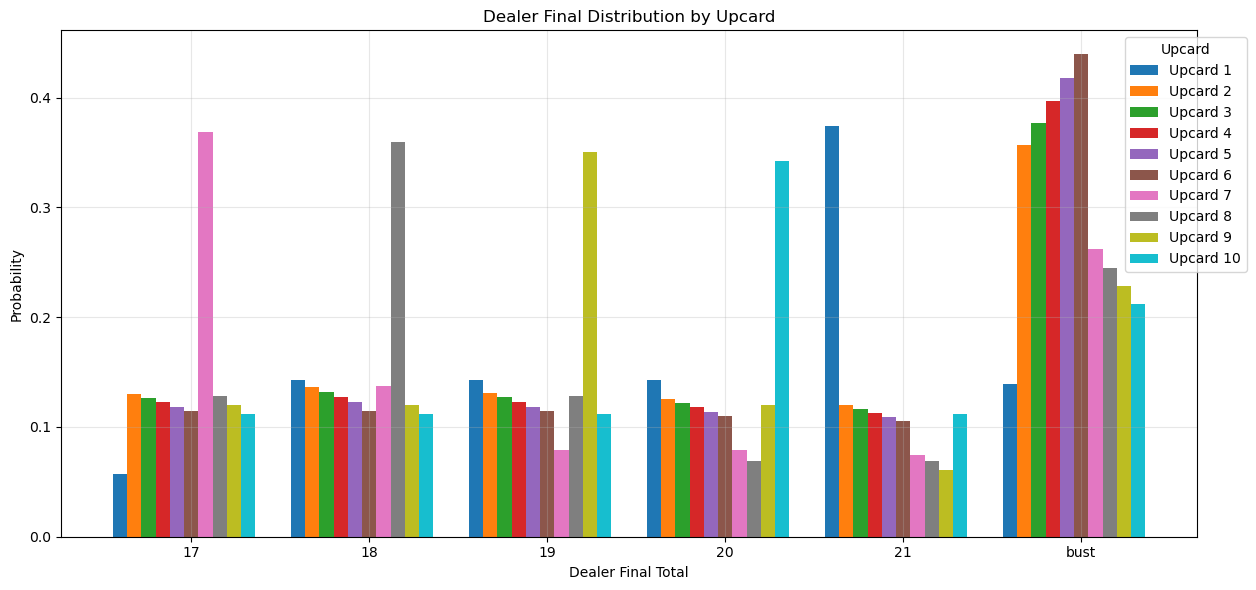

In [37]:
outcomes = [17, 18, 19, 20, 21, 'bust']
upcards = list(dealer_dist.keys())  # [1, 2, 3, ..., 10]

x = np.arange(len(outcomes))  # positions for each outcome on x-axis
width = 0.08 # width of each bar

plt.figure(figsize=(14, 6))

for i, upcard in enumerate(upcards):
    probs = [dealer_dist[upcard].get(o, 0) for o in outcomes]  # get prob for each outcome
    plt.bar(x + i * width, probs, width=width, label=f'Upcard {upcard}')

plt.xticks(x + width * len(upcards) / 2, outcomes)  # center x labels
plt.xlabel('Dealer Final Total')
plt.ylabel('Probability')
plt.title('Dealer Final Distribution by Upcard')
plt.legend(title='Upcard', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

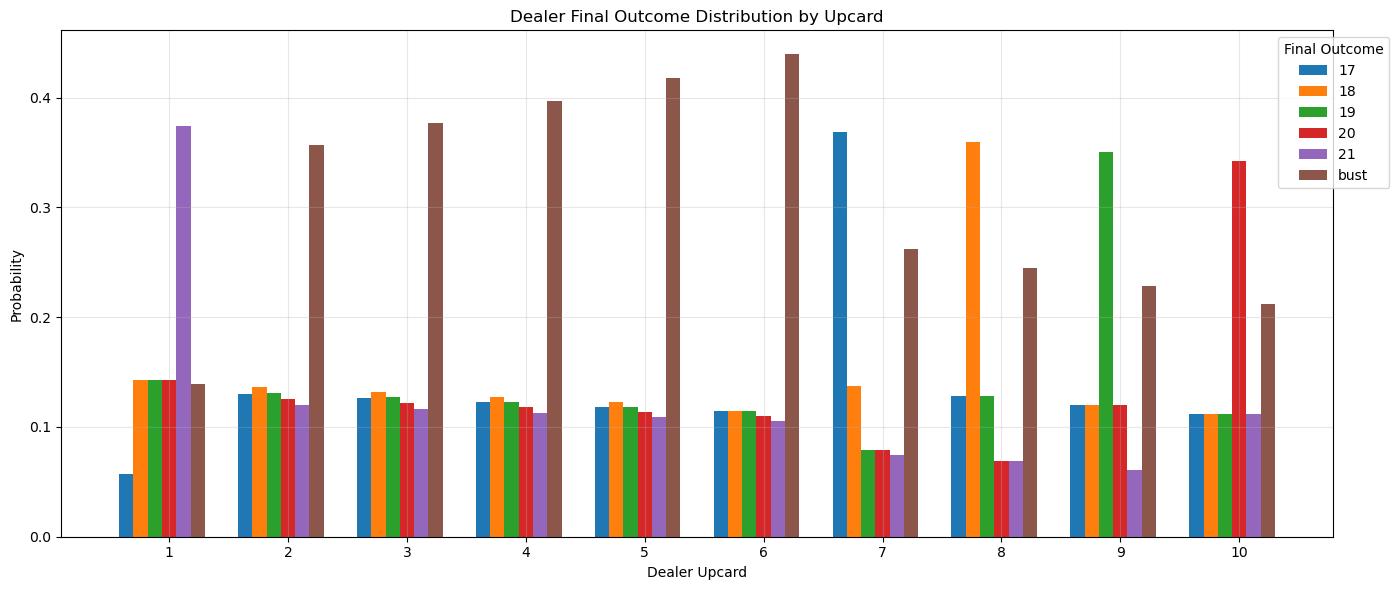

In [38]:
x = np.arange(len(upcards))  # one position per upcard
width = 0.12  # width of each bar

plt.figure(figsize=(14, 6))

for i, outcome in enumerate(outcomes):
    probs = [dealer_dist[up].get(outcome, 0) for up in upcards]
    plt.bar(x + i * width, probs, width=width, label=str(outcome))

plt.xticks(x + width * len(outcomes) / 2, upcards)

plt.xlabel('Dealer Upcard')
plt.ylabel('Probability')
plt.title('Dealer Final Outcome Distribution by Upcard')

plt.legend(title='Final Outcome', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

#### Standing player

##### P(WIN) IF PLAYER STANDS
    - Player stands with some total T.
    - Player wins if dealer busts OR dealer final total < T
    - Player draws if dealer final total == T
    - Player loses if dealer final total > T

In [39]:
def p_win_stand(player_total, upcard):
    dist  = dealer_dist[upcard]
    p_win = p_draw = p_lose = 0.0

    for outcome, prob in dist.items():
        if outcome == 'bust':
            p_win += prob  # dealer bust -> player wins
        elif outcome < player_total:
            p_win += prob  # dealer lower -> player wins
        elif outcome == player_total:
            p_draw += prob # draw -> push
        else:
            p_lose += prob # dealer higher -> player loses

    ev = p_win - p_lose  # EV = +1*p_win + 0*draw + -1*p_lose
    return p_win, p_draw, p_lose, ev

In [40]:
dealer_dist[3]

{'bust': 0.3766821131039142,
 18: 0.1319570087124231,
 19: 0.12705521955938223,
 20: 0.12180330260969563,
 21: 0.11617432495592891,
 17: 0.1263280310586564}

In [41]:
# test 
p_win_stand(10, 3)
# res
# p_win, p_draw, p_lose, ev

(0.3766821131039142, 0.0, 0.6233178868960864, -0.24663577379217216)

In [56]:
data = []

for i in range(4, 22):  # 4-21
    row = []
    for j in range(1, 11):  # 1-10
        row.append(p_win_stand(i, j))
    data.append(row)

data

[[(0.13892038385793903, 0.0, 0.8610796161420612, -0.7221592322841222),
  (0.3567278495798524, 0.0, 0.6432721504201476, -0.28654430084029525),
  (0.3766821131039142, 0.0, 0.6233178868960864, -0.24663577379217216),
  (0.3970751569584727, 0.0, 0.6029248430415275, -0.20584968608305482),
  (0.41765875287585813, 0.0, 0.5823412471241419, -0.1646824942482838),
  (0.43946657490174357, 0.0, 0.5605334250982562, -0.12106685019651264),
  (0.26231240836153297, 0.0, 0.7376875916384669, -0.4753751832769339),
  (0.2447412422511913, 0.0, 0.7552587577488088, -0.5105175154976175),
  (0.22842515943444527, 0.0, 0.7715748405655549, -0.5431496811311096),
  (0.21210907661769912, 0.0, 0.7878909233823008, -0.5757818467646016)],
 [(0.13892038385793903, 0.0, 0.8610796161420612, -0.7221592322841222),
  (0.3567278495798524, 0.0, 0.6432721504201476, -0.28654430084029525),
  (0.3766821131039142, 0.0, 0.6233178868960864, -0.24663577379217216),
  (0.3970751569584727, 0.0, 0.6029248430415275, -0.20584968608305482),
  (0.

#### Hitting player

##### P(WIN) IF PLAYER HITS 
##### Player draws one card.
    - If bust -> lose immediately
    - If not bust -> player stands at new total, compute p_win_stand
    
##### Ace case
    - If player draws Ace and new total+11 <= 21 -> use 11
    - If new total > 21 and player has soft Ace then flip it!!

In [58]:
def p_win_hit(player_total, has_soft_ace, upcard):
    p_win = p_draw = p_lose = 0.0

    for card in cards:
        p = card_prob[card]
        new_total   = player_total + card # hit update
        new_has_ace = has_soft_ace

        # drawing an Ace
        if card == 1:
            if player_total + 11 <= 21:
                new_total = player_total + 11
                new_has_ace = True
            else:
                new_total   = player_total + 1

        # busted but still have soft Ace
        if new_total > 21 and new_has_ace:
            new_total -= 10
            new_has_ace = False

        # real busted
        if new_total > 21:
            p_lose += p 
        else: #after hitting, player stands at new_total
            w, d, l, _ = p_win_stand(new_total, upcard)
            p_win  += p * w
            p_draw += p * d
            p_lose += p * l

    ev = p_win - p_lose
    return p_win, p_draw, p_lose, ev

#### Strategy Table
    - For every (player_total, dealer_upcard):
        - Compare EV(stand) vs EV(hit)
        - Choose whichever gives higher EV

In [59]:
#initialize values
dealer_upcards  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
upcard_labels   = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10']

# hard totals: 4 to 21
hard_totals = list(range(4, 22))

# soft totals: Soft 13 (Ace+2) to Soft 21 (Ace+10)
soft_totals = list(range(13, 22))

results_hard = {}   # (total, upcard) -> { action, ev, pw, pd, pl }
results_soft = {}

In [60]:
# hard 
for total in hard_totals: # 4-21
    for upcard in dealer_upcards:

        pw_s, pd_s, pl_s, ev_s = p_win_stand(total, upcard) # stand: win, draw , lose, ev
        pw_h, pd_h, pl_h, ev_h = p_win_hit(total, False, upcard) # hit: win, hit, lose, ev
        # hard -> no soft ace

        if ev_h > ev_s:
            action = 'H'
            pw, pd, pl, ev = pw_h, pd_h, pl_h, ev_h
        else:
            action = 'S'
            pw, pd, pl, ev = pw_s, pd_s, pl_s, ev_s

        results_hard[(total, upcard)] = {
            'action': action,
            'ev': round(ev, 4),
            'p_win': round(pw, 4),
            'p_draw': round(pd, 4),
            'p_lose': round(pl, 4),
        }
for i, (key, value) in enumerate(results_hard.items()):
    if i >= 5:
        break
    print(f"{key}: {value}")

(4, 1): {'action': 'S', 'ev': -0.7222, 'p_win': 0.1389, 'p_draw': 0.0, 'p_lose': 0.8611}
(4, 2): {'action': 'S', 'ev': -0.2865, 'p_win': 0.3567, 'p_draw': 0.0, 'p_lose': 0.6433}
(4, 3): {'action': 'H', 'ev': -0.2466, 'p_win': 0.3767, 'p_draw': 0.0, 'p_lose': 0.6233}
(4, 4): {'action': 'S', 'ev': -0.2058, 'p_win': 0.3971, 'p_draw': 0.0, 'p_lose': 0.6029}
(4, 5): {'action': 'H', 'ev': -0.1647, 'p_win': 0.4177, 'p_draw': 0.0, 'p_lose': 0.5823}


In [61]:
# soft
for total in soft_totals: # 13-21
    for upcard in dealer_upcards:

        pw_s, pd_s, pl_s, ev_s = p_win_stand(total, upcard)
        pw_h, pd_h, pl_h, ev_h = p_win_hit(total, True, upcard)   # soft -> has ace

        if ev_h > ev_s:
            action = 'H'
            pw, pd, pl, ev = pw_h, pd_h, pl_h, ev_h
        else:
            action = 'S'
            pw, pd, pl, ev = pw_s, pd_s, pl_s, ev_s

        results_soft[(total, upcard)] = {
            'action': action,
            'ev': round(ev, 4),
            'p_win': round(pw, 4),
            'p_draw': round(pd, 4),
            'p_lose': round(pl, 4),
        }
for i, (key, value) in enumerate(results_soft.items()):
    if i >= 5:
        break
    print(f"{key}: {value}")

(13, 1): {'action': 'H', 'ev': -0.4884, 'p_win': 0.2227, 'p_draw': 0.0662, 'p_lose': 0.7111}
(13, 2): {'action': 'H', 'ev': -0.0342, 'p_win': 0.4581, 'p_draw': 0.0495, 'p_lose': 0.4924}
(13, 3): {'action': 'H', 'ev': -0.0022, 'p_win': 0.4749, 'p_draw': 0.0479, 'p_lose': 0.4771}
(13, 4): {'action': 'H', 'ev': 0.0305, 'p_win': 0.4921, 'p_draw': 0.0464, 'p_lose': 0.4616}
(13, 5): {'action': 'H', 'ev': 0.0636, 'p_win': 0.5094, 'p_draw': 0.0448, 'p_lose': 0.4458}


#### Table

In [62]:
def print_strategy_table(title, totals, row_prefix, results):
    col_w   = 8
    label_w = 12

    print(f"\n{'='*96}")
    print(f" {title}")
    print(f"{'='*96}")

    # Header
    header = f"{'Player':{label_w}}"
    for lbl in upcard_labels:
        header += f"{'D='+lbl:>{col_w}}"
    print(header)
    print("-" * (label_w + col_w * 10))

    for total in totals:
        row = f"{row_prefix+str(total):{label_w}}"
        for upcard in dealer_upcards:
            action = results[(total, upcard)]['action']
            row += f"{'['+action+']':>{col_w}}"
        print(row)

In [63]:

def print_ev_table(title, totals, row_prefix, results):
    col_w   = 8
    label_w = 12

    print(f"\n{'='*96}")
    print(f" {title}")
    print(f"{'='*96}")

    header = f"{'Player':{label_w}}"
    for lbl in upcard_labels:
        header += f"{'D='+lbl:>{col_w}}"
    print(header)
    print("-" * (label_w + col_w * 10))

    for total in totals:
        row = f"{row_prefix+str(total):{label_w}}"
        for upcard in dealer_upcards:
            ev = results[(total, upcard)]['ev']
            row += f"{ev:>{col_w}.4f}"
        print(row)

In [64]:
def print_prob_table(title, totals, row_prefix, results, key):
    col_w   = 8
    label_w = 12

    print(f"\n{'='*96}")
    print(f"{title}")
    print(f"{'='*96}")

    header = f"{'Player':{label_w}}"
    for lbl in upcard_labels:
        header += f"{'D='+lbl:>{col_w}}"
    print(header)
    print("-" * (label_w + col_w * 10))

    for total in totals:
        row = f"{row_prefix+str(total):{label_w}}"
        for upcard in dealer_upcards:
            val = results[(total, upcard)][key]
            row += f"{val:>{col_w}.4f}"
        print(row)

In [65]:
# hard table
print_strategy_table("STRATEGY TABLE — HARD TOTALS  [H]=Hit  [S]=Stand",hard_totals, "Hard ", results_hard)


 STRATEGY TABLE — HARD TOTALS  [H]=Hit  [S]=Stand
Player           D=A     D=2     D=3     D=4     D=5     D=6     D=7     D=8     D=9    D=10
--------------------------------------------------------------------------------------------
Hard 4           [S]     [S]     [H]     [S]     [H]     [S]     [S]     [S]     [S]     [S]
Hard 5           [S]     [S]     [H]     [S]     [H]     [S]     [S]     [S]     [S]     [S]
Hard 6           [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Hard 7           [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Hard 8           [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Hard 9           [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Hard 10          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Hard 11          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Hard 12          [H

In [66]:
# soft table
print_strategy_table("STRATEGY TABLE — SOFT TOTALS  [H]=Hit  [S]=Stand",soft_totals, "Soft ", results_soft)


 STRATEGY TABLE — SOFT TOTALS  [H]=Hit  [S]=Stand
Player           D=A     D=2     D=3     D=4     D=5     D=6     D=7     D=8     D=9    D=10
--------------------------------------------------------------------------------------------
Soft 13          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Soft 14          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Soft 15          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Soft 16          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Soft 17          [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]     [H]
Soft 18          [H]     [S]     [S]     [S]     [S]     [S]     [S]     [S]     [H]     [H]
Soft 19          [S]     [S]     [S]     [S]     [S]     [S]     [S]     [S]     [S]     [S]
Soft 20          [S]     [S]     [S]     [S]     [S]     [S]     [S]     [S]     [S]     [S]
Soft 21          [S

In [67]:
# hard expected val
print_ev_table("EXPECTED VALUE TABLE — HARD TOTALS  (EV = P_win - P_lose)",hard_totals, "Hard ", results_hard)


 EXPECTED VALUE TABLE — HARD TOTALS  (EV = P_win - P_lose)
Player           D=A     D=2     D=3     D=4     D=5     D=6     D=7     D=8     D=9    D=10
--------------------------------------------------------------------------------------------
Hard 4       -0.7222 -0.2865 -0.2466 -0.2058 -0.1647 -0.1211 -0.4754 -0.5105 -0.5431 -0.5758
Hard 5       -0.7222 -0.2865 -0.2466 -0.2058 -0.1647 -0.1211 -0.4754 -0.5105 -0.5431 -0.5758
Hard 6       -0.7177 -0.2765 -0.2369 -0.1964 -0.1556 -0.1122 -0.4470 -0.5006 -0.5339 -0.5672
Hard 7       -0.6846 -0.2160 -0.1782 -0.1396 -0.1006 -0.0592 -0.2947 -0.4235 -0.4785 -0.5158
Hard 8       -0.5964 -0.1033 -0.0691 -0.0341  0.0013  0.0379 -0.0939 -0.2260 -0.3593 -0.4215
Hard 9       -0.4664  0.0294  0.0594  0.0900  0.1211  0.1524  0.0521 -0.0132 -0.1505 -0.2923
Hard 10      -0.2966  0.1785  0.2037  0.2296  0.2558  0.2825  0.1962  0.1433  0.0722 -0.0750
Hard 11      -0.1772  0.2351  0.2587  0.2828  0.3072  0.3323  0.2314  0.1753  0.1139  0.0297
Hard 12   

In [68]:
# hard prob
print_prob_table("P(WIN) TABLE — HARD TOTALS",hard_totals, "Hard ", results_hard, 'p_win')


P(WIN) TABLE — HARD TOTALS
Player           D=A     D=2     D=3     D=4     D=5     D=6     D=7     D=8     D=9    D=10
--------------------------------------------------------------------------------------------
Hard 4        0.1389  0.3567  0.3767  0.3971  0.4177  0.4395  0.2623  0.2447  0.2284  0.2121
Hard 5        0.1389  0.3567  0.3767  0.3971  0.4177  0.4395  0.2623  0.2447  0.2284  0.2121
Hard 6        0.1389  0.3567  0.3767  0.3971  0.4177  0.4395  0.2623  0.2447  0.2284  0.2121
Hard 7        0.1433  0.3667  0.3864  0.4065  0.4268  0.4483  0.2907  0.2546  0.2377  0.2207
Hard 8        0.1720  0.4173  0.4354  0.4539  0.4726  0.4925  0.4147  0.3218  0.2838  0.2635
Hard 9        0.2316  0.4794  0.4955  0.5120  0.5287  0.5455  0.4915  0.4522  0.3569  0.3150
Hard 10       0.3021  0.5500  0.5638  0.5780  0.5924  0.6070  0.5607  0.5346  0.4926  0.3927
Hard 11       0.3351  0.5790  0.5920  0.6052  0.6187  0.6324  0.5788  0.5506  0.5203  0.4717
Hard 12       0.1800  0.3484  0.3590  0.39

In [69]:
# soft prob
print_prob_table("P(WIN) TABLE — SOFT TOTALS",soft_totals, "Soft ", results_soft, 'p_win')


P(WIN) TABLE — SOFT TOTALS
Player           D=A     D=2     D=3     D=4     D=5     D=6     D=7     D=8     D=9    D=10
--------------------------------------------------------------------------------------------
Soft 13       0.2227  0.4581  0.4749  0.4921  0.5094  0.5275  0.4257  0.3923  0.3562  0.3156
Soft 14       0.2227  0.4581  0.4749  0.4921  0.5094  0.5275  0.4257  0.3923  0.3562  0.3156
Soft 15       0.2227  0.4581  0.4749  0.4921  0.5094  0.5275  0.4257  0.3923  0.3562  0.3156
Soft 16       0.2227  0.4581  0.4749  0.4921  0.5094  0.5275  0.4257  0.3923  0.3562  0.3156
Soft 17       0.2227  0.4581  0.4749  0.4921  0.5094  0.5275  0.4257  0.3923  0.3562  0.3156
Soft 18       0.2360  0.4869  0.5030  0.5195  0.5360  0.5543  0.6309  0.3733  0.3839  0.3413
Soft 19       0.3396  0.6234  0.6350  0.6468  0.6589  0.6691  0.7687  0.7326  0.4684  0.4350
Soft 20       0.4828  0.7547  0.7620  0.7695  0.7773  0.7840  0.8473  0.8612  0.8192  0.5464
Soft 21       0.6260  0.8804  0.8838  0.88

In [70]:
# conversion for plotting
# build EV matrices
ev_hard = np.array([[results_hard[(t, u)]['ev']for u in dealer_upcards] for t in hard_totals])
ev_soft = np.array([[results_soft[(t, u)]['ev']for u in dealer_upcards] for t in soft_totals])

# build action matrices
action_hard = [[results_hard[(t, u)]['action']for u in dealer_upcards] for t in hard_totals]
action_soft = [[results_soft[(t, u)]['action']for u in dealer_upcards] for t in soft_totals]

# bust probabilities
bust_prob = [dealer_dist[u].get('bust', 0) for u in dealer_upcards]

#### EV heatmap

C:\Users\Acer\AppData\Local\Temp\ipykernel_8044\1370649491.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


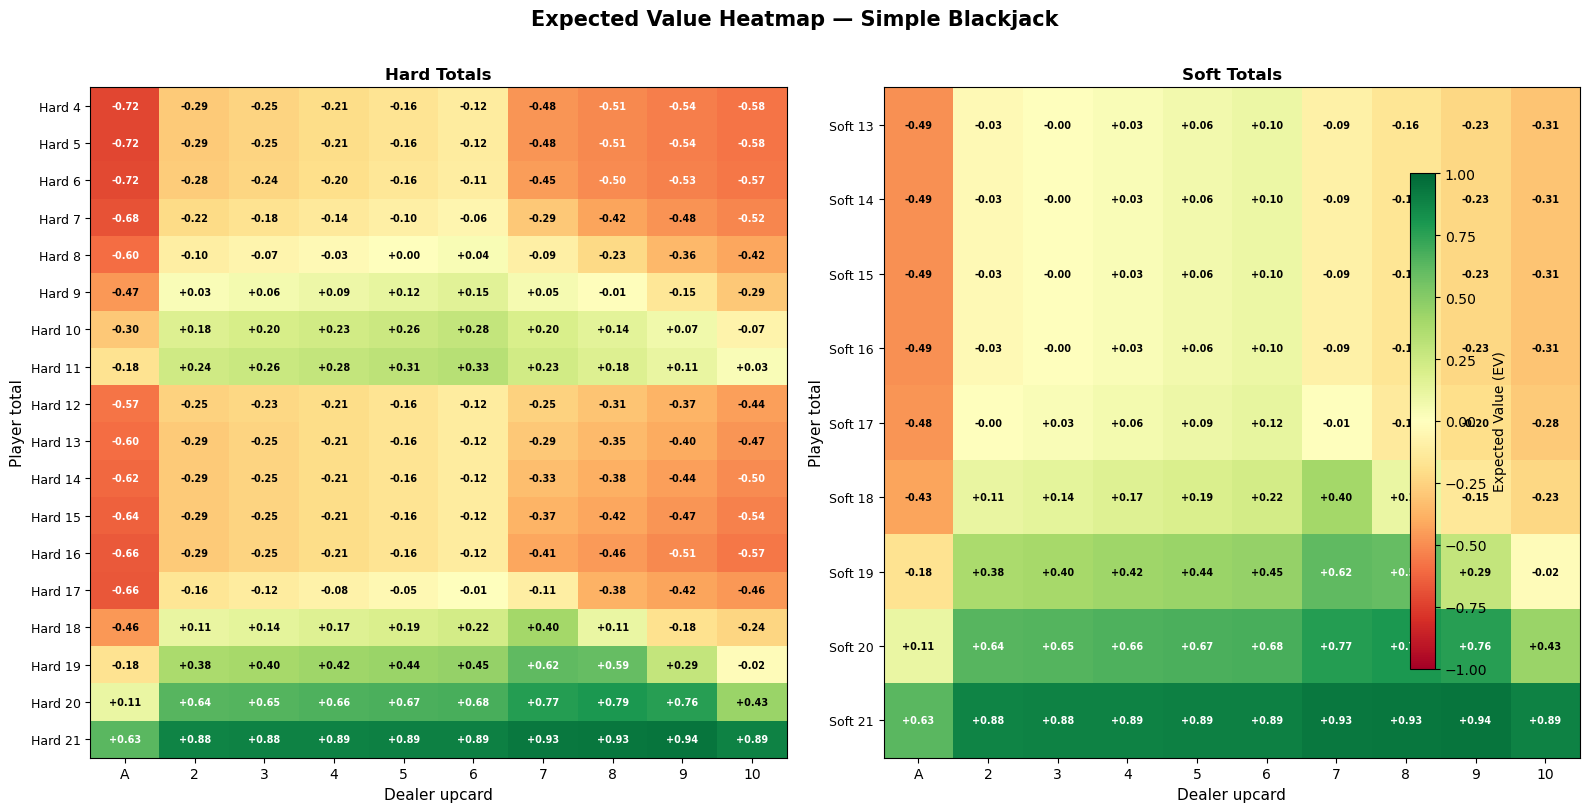

In [71]:
# EV Heatmap
# red = bad EV (you will likely lose)
# green = good EV (you will likely win)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Expected Value Heatmap — Simple Blackjack', fontsize=15, fontweight='bold', y=1.01)

# shared color scale so both plots use same red-white-green range
vmin, vmax = -1.0, 1.0
cmap = plt.cm.RdYlGn   # red -> yellow -> green

for ax, ev_matrix, row_labels, title in [
    (axes[0], ev_hard, [f'Hard {t}' for t in hard_totals], 'Hard Totals'),
    (axes[1], ev_soft, [f'Soft {t}' for t in soft_totals], 'Soft Totals'),
]:
    im = ax.imshow(ev_matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(10))
    ax.set_xticklabels(upcard_labels)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xlabel('Dealer upcard', fontsize=11)
    ax.set_ylabel('Player total',  fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

    # print EV value inside each cell
    for i in range(ev_matrix.shape[0]):
        for j in range(ev_matrix.shape[1]):
            val = ev_matrix[i, j]
            # white text on dark cells, black on light cells
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center',
                    fontsize=7, color=color, fontweight='bold')

# shared colorbar
fig.colorbar(im, ax=axes, orientation='vertical', label='Expected Value (EV)',
             fraction=0.02, pad=0.04)

plt.tight_layout()
plt.savefig('plot1_ev_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### dealer bust probability

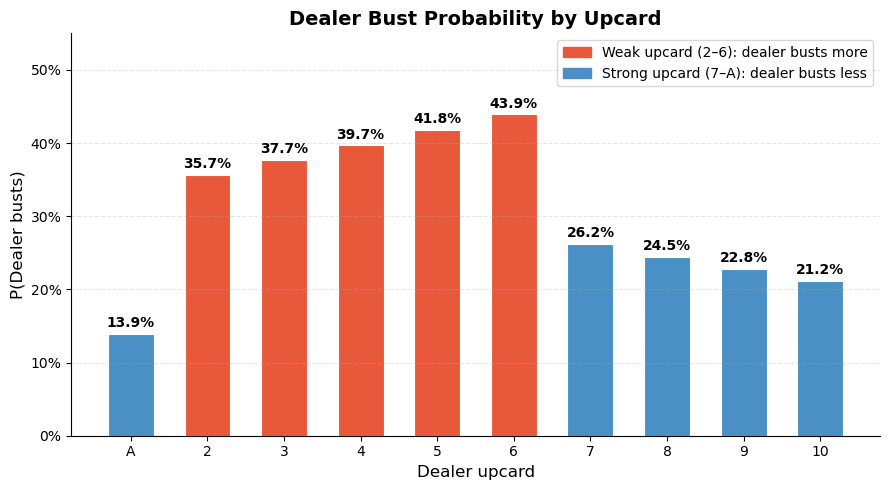

In [72]:
# dealer Bust Probability per Upcard

fig, ax = plt.subplots(figsize=(9, 5))

# color each bar: weak upcards (2-6) in coral, strong in steel blue
bar_colors = ['#E8593C' if u in [2,3,4,5,6] else '#4A90C4' for u in dealer_upcards]

bars = ax.bar(upcard_labels, bust_prob, color=bar_colors,
              edgecolor='white', linewidth=0.8, width=0.6)

# value labels on top of each bar
for bar, val in zip(bars, bust_prob):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.1%}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Dealer upcard', fontsize=12)
ax.set_ylabel('P(Dealer busts)', fontsize=12)
ax.set_title('Dealer Bust Probability by Upcard', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.55)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend = [
    Patch(color='#E8593C', label='Weak upcard (2–6): dealer busts more'),
    Patch(color='#4A90C4', label='Strong upcard (7–A): dealer busts less'),
]
ax.legend(handles=legend, fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('plot2_dealer_bust.png', dpi=150, bbox_inches='tight')
plt.show()

#### variance per hand

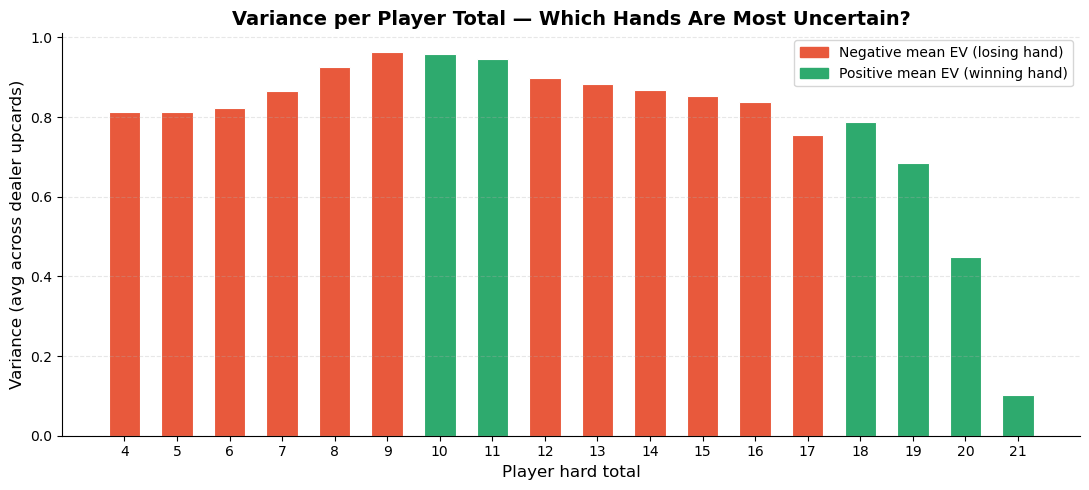

In [73]:
# variance per hard hand
# shows which player totals are riskiest
# var = P(win) + P(lose) - EV^2

# compute variance averaged across all dealer upcards
var_hard = []
for i, total in enumerate(hard_totals):
    cell_vars = []
    for j, upcard in enumerate(dealer_upcards):
        ev  = ev_hard[i, j]
        # P(win) and P(lose) from dealer distribution
        dist = dealer_dist[upcard]
        pw = sum(p for o, p in dist.items() if o == 'bust' or (o != 'bust' and o < total))
        pl = sum(p for o, p in dist.items() if o != 'bust' and o > total)
        var = (pw + pl) - ev**2
        cell_vars.append(var)
    var_hard.append(np.mean(cell_vars))

fig, ax = plt.subplots(figsize=(11, 5))

# color by EV — high variance + negative EV = most dangerous
mean_ev = [np.mean(ev_hard[i, :]) for i in range(len(hard_totals))]
bar_colors = ['#E8593C' if e < 0 else '#2EAA6E' for e in mean_ev]

bars = ax.bar([str(t) for t in hard_totals], var_hard,
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6)

ax.set_xlabel('Player hard total', fontsize=12)
ax.set_ylabel('Variance (avg across dealer upcards)', fontsize=12)
ax.set_title('Variance per Player Total — Which Hands Are Most Uncertain?', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend = [
    Patch(color='#E8593C', label='Negative mean EV (losing hand)'),
    Patch(color='#2EAA6E', label='Positive mean EV (winning hand)'),
]
ax.legend(handles=legend, fontsize=10)

plt.tight_layout()
plt.savefig('plot4_variance.png', dpi=150, bbox_inches='tight')
plt.show()

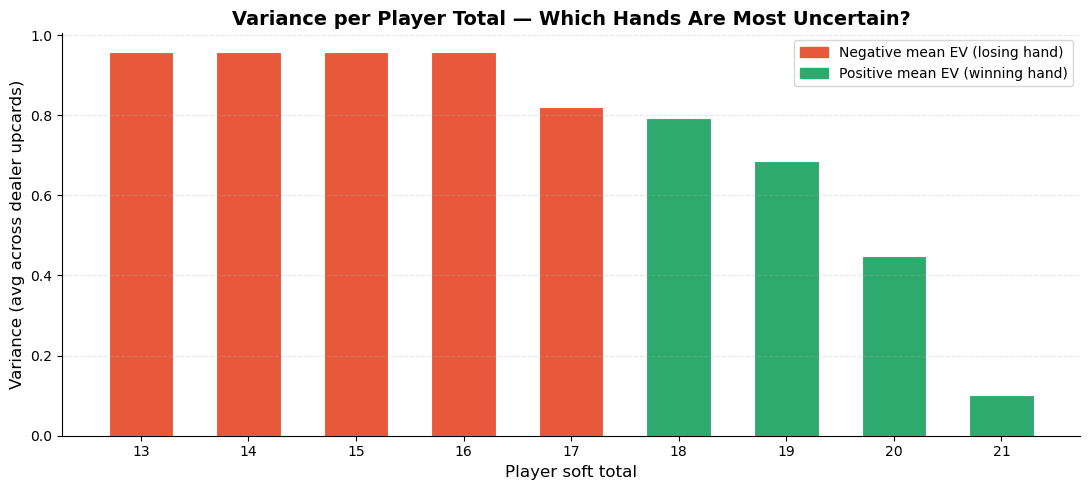

In [77]:
# variance per soft hand
# shows which player totals are riskiest
# var = P(win) + P(lose) - EV^2

# compute variance averaged across all dealer upcards
var_soft = []
for i, total in enumerate(soft_totals):
    cell_vars = []
    for j, upcard in enumerate(dealer_upcards):
        ev  = ev_soft[i, j]
        # P(win) and P(lose) from dealer distribution
        dist = dealer_dist[upcard]
        pw = sum(p for o, p in dist.items() if o == 'bust' or (o != 'bust' and o < total))
        pl = sum(p for o, p in dist.items() if o != 'bust' and o > total)
        var = (pw + pl) - ev**2
        cell_vars.append(var)
    var_soft.append(np.mean(cell_vars))

fig, ax = plt.subplots(figsize=(11, 5))

# color by EV — high variance + negative EV = most dangerous
mean_ev = [np.mean(ev_soft[i, :]) for i in range(len(soft_totals))]
bar_colors = ['#E8593C' if e < 0 else '#2EAA6E' for e in mean_ev]

bars = ax.bar([str(t) for t in soft_totals], var_soft,
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.6)

ax.set_xlabel('Player soft total', fontsize=12)
ax.set_ylabel('Variance (avg across dealer upcards)', fontsize=12)
ax.set_title('Variance per Player Total — Which Hands Are Most Uncertain?', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend = [
    Patch(color='#E8593C', label='Negative mean EV (losing hand)'),
    Patch(color='#2EAA6E', label='Positive mean EV (winning hand)'),
]
ax.legend(handles=legend, fontsize=10)

plt.savefig('plot5_variancesoft.png')
plt.tight_layout()
plt.show()

#### hit-stand decision boundary

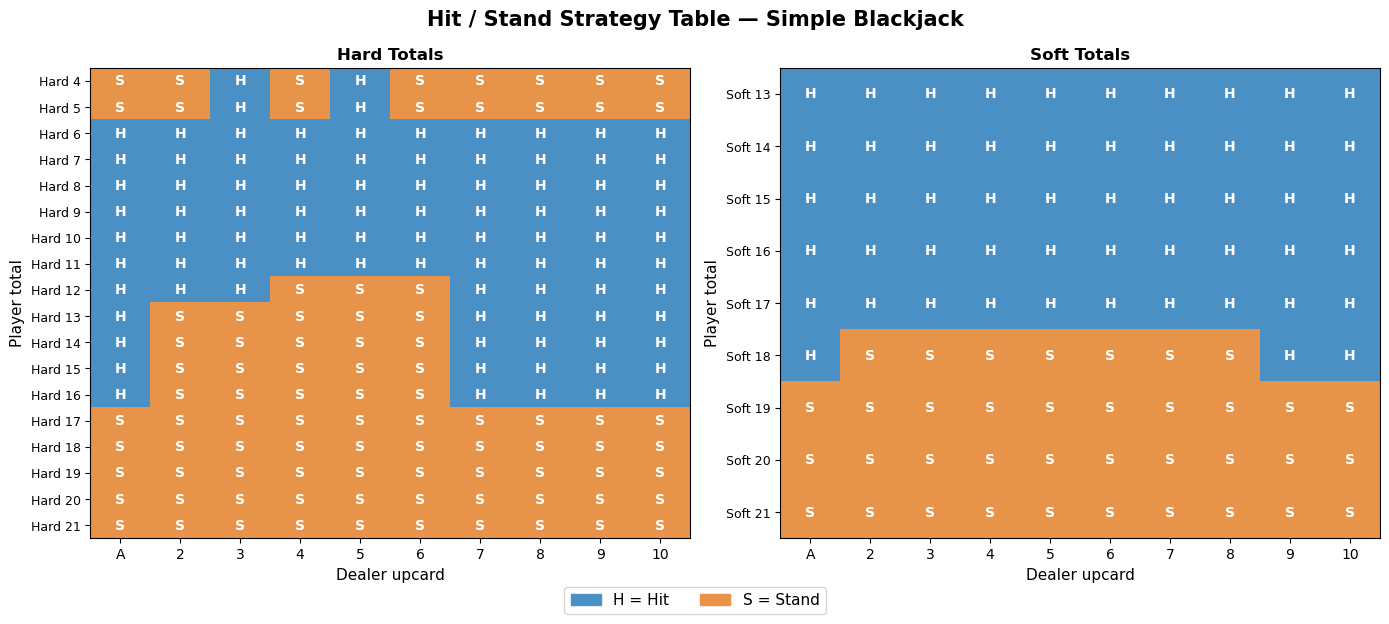

In [75]:
# Hit vs Stand Decision Boundary
# blue = Hit, orange = Stand

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Hit / Stand Strategy Table — Simple Blackjack', fontsize=15, fontweight='bold')

for ax, action_matrix, row_labels, title in [
    (axes[0], action_hard, [f'Hard {t}' for t in hard_totals], 'Hard Totals'),
    (axes[1], action_soft, [f'Soft {t}' for t in soft_totals], 'Soft Totals'),
]:
    n_rows = len(action_matrix)
    n_cols = len(action_matrix[0])

    # convert H/S to 0/1 for coloring
    grid = np.array([[0 if a in ('Hit', 'H') else 1 for a in row] for row in action_matrix])
    
    # 0 = blue (Hit), 1 = orange (Stand)
    cmap_hs = mcolors.ListedColormap(['#4A90C4', '#E8934A'])
    ax.imshow(grid, cmap=cmap_hs, vmin=0, vmax=1, aspect='auto')

    for i in range(n_rows):
        for j in range(n_cols):
            label = action_matrix[i][j][0]   # 'H' or 'S'
            ax.text(j, i, label, ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

    ax.set_xticks(range(10))
    ax.set_xticklabels(upcard_labels)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xlabel('Dealer upcard', fontsize=11)
    ax.set_ylabel('Player total',  fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend = [
    Patch(color='#4A90C4', label='H = Hit'),
    Patch(color='#E8934A', label='S = Stand'),
]
fig.legend(handles=legend, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

In [76]:
print(results_hard[(4, 1)]['action'])        
print(results_hard[(4, 1)]['action'] == 'H') 

S
False


In [27]:
print(f"\n{'='*60}")
print(f"  OVERALL SUMMARY")
print(f"{'='*60}")

all_ev   = []
all_var  = []

for results in [results_hard, results_soft]:
    for key, val in results.items():
        pw  = val['p_win']
        pl  = val['p_lose']
        ev  = val['ev']
        var = (pw + pl) - ev**2 # Var = E[X**2] - (E[X])**2
        all_ev.append(ev)
        all_var.append(var)

print(f"  Mean EV across all states  : {np.mean(all_ev):+.4f}")
print(f"  Mean Variance              :  {np.mean(all_var):.4f}")
print(f"  Best  EV (player best)     : {max(all_ev):+.4f}")
print(f"  Worst EV (player worst)    : {min(all_ev):+.4f}")
print(f"{'='*60}")


  OVERALL SUMMARY
  Mean EV across all states  : -0.0018
  Mean Variance              :  0.7489
  Best  EV (player best)     : +0.9392
  Worst EV (player worst)    : -0.7222


#### Interactive Game

In [28]:
def draw_card():
    values = [1,2,3,4,5,6,7,8,9,10,10,10,10]
    return random.choice(values)

In [34]:
def hand_total(cards):
    total = sum(cards)
    if 1 in cards and total + 10 <= 21:
        return total + 10, True
    return total, False

In [35]:
def ev_stand(player_total, upcard):
    total = max(4, min(21, player_total))
    if total in range(13, 22):  # could be soft
        return results_hard.get((total, upcard), {}).get('ev', 0)
    return results_hard.get((total, upcard), {}).get('ev', 0)

In [36]:
def best_action(player_total, is_soft, upcard):
    total = max(4, min(21, player_total))
    if is_soft:
        soft_total = max(13, min(21, total))
        action = results_soft.get((soft_total, upcard), {}).get('action', 'S')
    else:
        action = results_hard.get((total, upcard), {}).get('action', 'S')
    return 'Hit' if action == 'H' else 'Stand'

In [37]:
def play_game():
    stats = {'hands': 0, 'wins': 0, 'losses': 0, 'draws': 0, 'total_payoff': 0}

    while True:
        print("\n" + "="*45)
        print(f"  Hands:{stats['hands']}  W:{stats['wins']} L:{stats['losses']} D:{stats['draws']}", end="")
        if stats['hands'] > 0:
            print(f"  RunEV: {stats['total_payoff']/stats['hands']:+.3f}", end="")
        print()
        print("="*45)

        # deal
        player = [draw_card(), draw_card()]
        dealer = [draw_card(), draw_card()]
        upcard = min(dealer[0], 10)

        print(f"  Dealer shows : {dealer[0]}")
        print(f"  Your hand    : {player}  = {hand_total(player)[0]}")

        # player turn
        while True:
            total, soft = hand_total(player)
            hint = best_action(total, soft, upcard)
            ev_s = ev_stand(total, upcard)

            print(f"\n  Total: {total}{'(soft)' if soft else ''}")
            print(f"  Hint : {hint}  |  EV(stand)={ev_s:+.4f}")
            print("  [h]it  [s]tand  [q]uit")

            choice = input("  > ").strip().lower()

            if choice == 'q':
                print("\n  Thanks for playing ja ja ja ja ja!")
                return

            elif choice == 'h':
                new_card = draw_card()
                player.append(new_card)
                total, soft = hand_total(player)
                print(f"  Drew: {new_card}  →  hand: {player} = {total}")
                if total > 21:
                    print("  BUST! You lose.")
                    stats['hands']   += 1
                    stats['losses']  += 1
                    stats['total_payoff'] -= 1
                    break
                elif total == 21:
                    print("  21! Standing automatically.")
                    break

            elif choice == 's':
                break
            else:
                print("  Type h, s, or q")

        # dealer turn
        total, _ = hand_total(player)
        if total <= 21:
            print(f"\n  Dealer's hand: {dealer} = {hand_total(dealer)[0]}")
            while True:
                dt, ds = hand_total(dealer)
                if dt < 17 or (dt == 17 and ds):
                    new = draw_card()
                    dealer.append(new)
                    print(f"  Dealer draws {new} → {dealer} = {hand_total(dealer)[0]}")
                else:
                    break

            pt, _  = hand_total(player)
            dt, _  = hand_total(dealer)

            if dt > 21:
                print("  Dealer busts — YOU WIN! +1")
                stats['wins'] += 1; stats['total_payoff'] += 1
            elif dt > pt:
                print(f"  Dealer {dt} > Player {pt} — YOU LOSE. -1")
                stats['losses'] += 1; stats['total_payoff'] -= 1
            elif dt < pt:
                print(f"  Player {pt} > Dealer {dt} — YOU WIN! +1")
                stats['wins'] += 1; stats['total_payoff'] += 1
            else:
                print(f"  Both {pt} — DRAW. 0")
                stats['draws'] += 1

            stats['hands'] += 1

In [ ]:
play_game()


  Hands:0  W:0 L:0 D:0
  Dealer shows : 10
  Your hand    : [10, 7]  = 17

  Total: 17
  Hint : Stand  |  EV(stand)=-0.4644
  [h]it  [s]tand  [q]uit


  >  s



  Dealer's hand: [10, 4] = 14
  Dealer draws 6 → [10, 4, 6] = 20
  Dealer 20 > Player 17 — YOU LOSE. -1

  Hands:1  W:0 L:1 D:0  RunEV: -1.000
  Dealer shows : 2
  Your hand    : [1, 10]  = 21

  Total: 21(soft)
  Hint : Stand  |  EV(stand)=+0.8804
  [h]it  [s]tand  [q]uit


  >  s



  Dealer's hand: [2, 5] = 7
  Dealer draws 7 → [2, 5, 7] = 14
  Dealer draws 8 → [2, 5, 7, 8] = 22
  Dealer busts — YOU WIN! +1

  Hands:2  W:1 L:1 D:0  RunEV: +0.000
  Dealer shows : 10
  Your hand    : [9, 10]  = 19

  Total: 19
  Hint : Stand  |  EV(stand)=-0.0187
  [h]it  [s]tand  [q]uit
